# Unsupervised Text Classification

Using LLMs to categorize responses seems to be pretty unreliable and I have been unsuccessful in getting the models to cleanly work. 
In this document, I discuss using `BERTopic` to create categories of responses. This seems to be a fairly popular method in recent years.



## Questions

All responses can be found in `data/student-responses.csv`. In this file, all collected responses are stored from the bar chart and heatmap experiments. In the data cleaning script, a flag for bar chart or heatmap experiment was included.

In [1]:
# Import modules
import pandas as pd

# Read dataset
df = pd.read_csv("../data/student-responses.csv")

# Filter only Bar Chart experiment responses
df = df[df["experiment"] == "Bar chart"]
df.head()

,id,section_sis_id,section,attempt,What components of the experiment are clearer now than they were as a participant What questions do you still have for the experimenter Write 3 5 sentences reflecting on the abstract,Paste the response code you received after participating in the graphics experiment here,As of today I am at least 19 years of age,My instructor may share my reflection responses with the researchers in this study,What do you think the purpose of the experiment was,What elements of experimental design such as randomization or the use of a control group do you think were present in the experiment Why,...,What sources of error are involved in this experiment,What variables were examined For each variable identify whether it was quantitative or categorical,In this class you ll be learning about the process of scientific investigation What do you think that process looks like from the perspective of a researcher compared to what it looks like from the perspective of someone in the general public who is a consumer of scientific results Write a paragraph at least 3 5 sentences about how you think science happens,How did the information you gained from the components of this project participation post study reflection extended abstract presentation differ,If you had to hear about this study using only the extended abstract or only the presentation which one would you prefer Which one would be better for determining whether the experiment was well designed,What components were emphasized in the presentation that weren t emphasized in the abstract Why do you think that is,What critiques do you have of this study and its design What would have made the study better,year,semester,experiment
0,15464f12481fd2057f7a8205a42e03e8,STAT-218-011.1241,1,1,Seeing the marked bar closer and in person rat...,40646-92578-95520-71653,True,I agree,To see how accurate the students can be with e...,I think this was a paried control group becaus...,...,There's no results in whether if you were clos...,Circle and Triangle graph. Quantitative,I think that’ll look a lot different to a pers...,They gave us charts and information that shows...,"Extended abstract, extended abstarct",2d and 3d bar graphs because they were trying ...,How do you know whether or not your response i...,2024,Spring,Bar chart
1,2800ab155946ad01714a453f448edbae,STAT-218-011.1241,1,1,I think it is clearer that this experiment is ...,53670-79351-03305-70518,True,I agree,I think the purpose was to determine is we cou...,I think the control group was the models we ha...,...,"It might be a sampling error, also people may ...",Model size- quantitative color- categorical,A researcher has to form a hypothesis and crea...,I think the presentation was the easiest to un...,I would prefer to hear about the study from th...,I think the presentation emphasized more of th...,I think this study has a big possibility for c...,2024,Spring,Bar chart
2,43c3004415a1e8390ac4e7df8d06a292,STAT-218-011.1241,1,1,The whole objective of the experiment is more ...,13531-97095-57767-17258,True,I agree,The purpose of the experiment was to determine...,Randomization was used because we were given d...,...,The people who did the experiment could have m...,The height which was quantitative and the othe...,The process of scientific investigation is jus...,During the participation and post-study reflec...,I would prefer the video just because abstract...,The component that was emphasized to me was th...,Maybe to explain the experiment better to the ...,2024,Spring,Bar chart
3,629669a5f6966aac68902888966f15be,STAT-218-011.1241,1,1,NaN,12068-97156-84567-38829,True,I agree,NaN,NaN,...,NaN,NaN,I believe that it will consist of the person b...,NaN,NaN,NaN,NaN,2024,Spring,Bar chart
4,7b3570d08b16b612f899afa0a3bc4801,NaN,1,1,NaN,NaN,True,I agree,NaN,NaN,...,NaN,NaN,I believe that scientific investigation is the...,NaN,NaN,NaN,NaN,2024,Spring,Bar chart


In [2]:
df["section"].value_counts().to_frame(name="count").reset_index().rename(columns={"index": "section"}).sort_values("section")

,section,count
29,1,9
27,2,10
1,3,47
25,4,13
28,5,10
20,6,16
21,7,15
11,8,20
4,9,38
8,10,23


Next, it is worth noting that the quesitons are not in order. Below is a table summary of the questions and their corresponding modules.

| Module | Question Number | Dataframe Column Index (0-index) | Prompt |
|---|---:|---:|---|
| pre-experiment | Q1 | 13 | In this class, you’ll be learning about the process of scientific investigation. What do you think that process looks like, from the perspective of a researcher, compared to what it looks like from the perspective of someone in the general public who is a consumer of scientific results? Write a paragraph (at least 3-5 sentences) about how you think science happens. |
| post-experiment | Q2 | 8 | What do you think the purpose of the experiment was? |
| post-experiment | Q3 | 10 | What hypotheses might the experimenter have been testing? |
| post-experiment | Q4 | 11 | What sources of error are involved in this experiment? |
| post-experiment | Q5 | 12 | What variables were examined? For each variable, identify whether it was quantitative or categorical. |
| post-experiment | Q6 | 9 | What elements of experimental design, such as randomization or the use of a control group, do you think were present in the experiment? Why? |
| abstract reflection | Q7 | 4 | What components of the experiment are clearer now than they were as a participant? What questions do you still have for the experimenter? Write 3-5 sentences reflecting on the abstract. |
| presentation reflection | Q8 | 14 | How did the information you gained from the components of this project (participation, post-study reflection, extended abstract, presentation) differ? |
| presentation reflection | Q9 | 16 | What components were emphasized in the presentation that weren’t emphasized in the abstract? Why do you think that is? |
| presentation reflection | Q10 | 17 | What critiques do you have of this study and its design? What would have made the study better? |
| presentation reflection | Q11 | 15 | If you had to hear about this study using only the extended abstract or only the presentation, which one would you prefer? Which one would be better for determining whether the experiment was well designed? |

## Side note

It looks like some students may have used AI in their answers. While I doubt that we could detect human text (tools seem to be unreliable for this task), we may want to remove these participants if their answers are completely off topic. 

- ac6eb19c384b5ec70af8f6b086758376: this user had some answers talking about cows, which is completely irrelevant to the sources of error question

## BERTopic

BERTopic is an unsupervised text classification method that leverages clustering and dimensional reduction. 

**Webpage:** <https://maartengr.github.io/BERTopic/index.html>

1. 

**Guide:** <https://www.youtube.com/watch?v=v3SePt3fr9g>

In [3]:
df.columns[13].split()

['In',
 'this',
 'class',
 'you',
 'll',
 'be',
 'learning',
 'about',
 'the',
 'process',
 'of',
 'scientific',
 'investigation',
 'What',
 'do',
 'you',
 'think',
 'that',
 'process',
 'looks',
 'like',
 'from',
 'the',
 'perspective',
 'of',
 'a',
 'researcher',
 'compared',
 'to',
 'what',
 'it',
 'looks',
 'like',
 'from',
 'the',
 'perspective',
 'of',
 'someone',
 'in',
 'the',
 'general',
 'public',
 'who',
 'is',
 'a',
 'consumer',
 'of',
 'scientific',
 'results',
 'Write',
 'a',
 'paragraph',
 'at',
 'least',
 '3',
 '5',
 'sentences',
 'about',
 'how',
 'you',
 'think',
 'science',
 'happens']

In [4]:
# Modules for topic modeling
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
import hdbscan
from umap import UMAP
import openai
from bertopic.representation import OpenAI
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

# Embedding model
embedding_model = SentenceTransformer("all-mpnet-base-v2")

# UMAP parameters tuned to preserve more neighborhood structure
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# HDBSCAN tuned to reduce outliers
hdb = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=1,
    allow_single_cluster=True,
    cluster_selection_method="eom",
    prediction_data=True
)

# Combine custom stop words with stop words from CountVectorizer
column_name = df.columns[4]
stop_words = text.ENGLISH_STOP_WORDS.union(column_name.split())
stop_words = [word for word in stop_words]

# Vectorizer model
vectorizer_model = CountVectorizer(
    #ngram_range=(1, 2),
    #stop_words='english',
    stop_words=stop_words,
    min_df=2,
    max_df=0.95
)

# Topic Representation model
ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True,
    bm25_weighting=True
)

# Configure OpenAI for topic representation
client = openai.OpenAI(
    base_url="http://localhost:11434/v1",
    api_key='ollama'
)

representation_model = OpenAI(client, 
                              system_prompt="You are a helpful assistant that summarizes the main themes of a collection of text responses. You will be given a list of representative responses, and you should generate a concise summary that captures the key themes and insights from those responses. Your summary should be clear, informative, and reflect the main ideas expressed in the representative responses.",
                              model='mistral')

# Alternate representation without LLM
representation_model = KeyBERTInspired()

# Fit model for Q1 responses
q1 = df.iloc[:, 4].dropna().astype(str).str.strip()
q1 = q1[q1.ne("")].tolist()

# Fit BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdb,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    nr_topics="auto",
    calculate_probabilities=True,
    verbose=True,
    representation_model=representation_model
)
topics, probs = topic_model.fit_transform(q1)

c:\Users\twied\Documents\R Directory\dissertation\ch2-experiential-learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13245.31it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 22:18:59,841 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 16/16 [00:27<00:00,  1.71s/it]
2026-04-12 22:19:27,187 - BERTopic - Embedding - Completed ✓
2026-04-12 22:19:27,187 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


In [5]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,73,-1_visualization_visually_design_visual,"[visualization, visually, design, visual, comp...","[Having read the abstract, I now have a cleare..."
1,0,239,0_visualization_chart_graph_perception,"[visualization, chart, graph, perception, visu...",[It's much clearer to me now that the research...
2,1,20,1_experiments_results_statistics_article,"[experiments, results, statistics, article, st...",[It is more clear to me the purpose of the exp...
3,2,16,2_proportion_percentages_visualize_scale,"[proportion, percentages, visualize, scale, he...",[It is now far more clear why we were asked to...
4,3,13,3_research_hypothesis_conclusions_science,"[research, hypothesis, conclusions, science, i...",[There were a couple of components of the expe...
5,4,11,4_graph_ratios_shiny_ratio,"[graph, ratios, shiny, ratio, randomness, indi...",[One thing that is clearer to me now is why we...
6,5,11,5_findings_experimenters_conclusions_conclusion,"[findings, experimenters, conclusions, conclus...",[The background of the experiment is much clea...
7,6,9,6_statistics_correlation_graphics_effect,"[statistics, correlation, graphics, effect, vi...",[One component that was clearer after reading ...
8,7,8,7_hypothesis_studies_analysis_randomness,"[hypothesis, studies, analysis, randomness, co...",[After seeing the presentation and reading the...
9,8,7,8_visually_visualize_graphics_observing,"[visually, visualize, graphics, observing, see...","[As a participant in the study, I had no idea ..."


In [6]:
#topic_model.reduce_topics(docs=q1, nr_topics=5)
topic_model.update_topics(q1, vectorizer_model=CountVectorizer(ngram_range=(1, 2), stop_words="english"))
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,73,-1_3d_study_experiment_graphs,"[3d, study, experiment, graphs, charts, 2d, di...","[Having read the abstract, I now have a cleare..."
1,0,239,0_3d_graphs_2d_experiment,"[3d, graphs, 2d, experiment, charts, bar, prin...",[It's much clearer to me now that the research...
2,1,20,1_experiment_results_purpose_know,"[experiment, results, purpose, know, purpose e...",[It is more clear to me the purpose of the exp...
3,2,16,2_bars_experiment_heights_clearer,"[bars, experiment, heights, clearer, questions...",[It is now far more clear why we were asked to...
4,3,13,3_experiment_understand_better understand_helped,"[experiment, understand, better understand, he...",[There were a couple of components of the expe...
5,4,11,4_app_bar sizes_shiny_sizes,"[app, bar sizes, shiny, sizes, randomly assign...",[One thing that is clearer to me now is why we...
6,5,11,5_experiment_abstract_study_process,"[experiment, abstract, study, process, insight...",[The background of the experiment is much clea...
7,6,9,6_study_estimate_comparing_goal study,"[study, estimate, comparing, goal study, goal,...",[One component that was clearer after reading ...
8,7,8,7_sense_step_makes_makes sense,"[sense, step, makes, makes sense, abstract, ma...",[After seeing the presentation and reading the...
9,8,7,8_visually impaired_impaired_visually_graphics...,"[visually impaired, impaired, visually, graphi...","[As a participant in the study, I had no idea ..."


In [7]:
# Perform hierarchical topic reduction
hierarchical_topics = topic_model.hierarchical_topics(q1)

# Visualize the subtopics
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 28/28 [00:00<00:00, 680.18it/s]


In [8]:
topic_model.visualize_topics()

In [9]:
topic_model.visualize_documents(q1, hide_annotations=True)

In [10]:
%pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


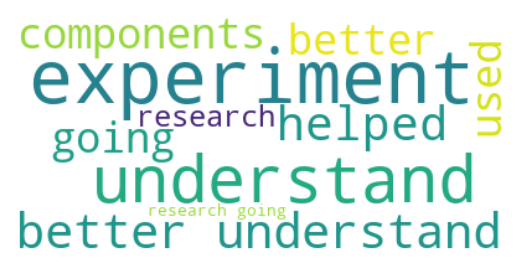

In [11]:
def create_wordcloud(model, topic):
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Show wordcloud
create_wordcloud(topic_model, topic=3)

----------------

# All Prompts

With a working example, it is time to convert this method into all of the prompts

## Data

In [1]:
# Import modules
import pandas as pd

# Read dataset
df = pd.read_csv("../data/student-responses.csv")

# Filter only Bar Chart experiment responses
df = df[df["experiment"] == "Bar chart"]
df.head()

,id,section_sis_id,section,attempt,What components of the experiment are clearer now than they were as a participant What questions do you still have for the experimenter Write 3 5 sentences reflecting on the abstract,Paste the response code you received after participating in the graphics experiment here,As of today I am at least 19 years of age,My instructor may share my reflection responses with the researchers in this study,What do you think the purpose of the experiment was,What elements of experimental design such as randomization or the use of a control group do you think were present in the experiment Why,...,What sources of error are involved in this experiment,What variables were examined For each variable identify whether it was quantitative or categorical,In this class you ll be learning about the process of scientific investigation What do you think that process looks like from the perspective of a researcher compared to what it looks like from the perspective of someone in the general public who is a consumer of scientific results Write a paragraph at least 3 5 sentences about how you think science happens,How did the information you gained from the components of this project participation post study reflection extended abstract presentation differ,If you had to hear about this study using only the extended abstract or only the presentation which one would you prefer Which one would be better for determining whether the experiment was well designed,What components were emphasized in the presentation that weren t emphasized in the abstract Why do you think that is,What critiques do you have of this study and its design What would have made the study better,year,semester,experiment
0,15464f12481fd2057f7a8205a42e03e8,STAT-218-011.1241,1,1,Seeing the marked bar closer and in person rat...,40646-92578-95520-71653,True,I agree,To see how accurate the students can be with e...,I think this was a paried control group becaus...,...,There's no results in whether if you were clos...,Circle and Triangle graph. Quantitative,I think that’ll look a lot different to a pers...,They gave us charts and information that shows...,"Extended abstract, extended abstarct",2d and 3d bar graphs because they were trying ...,How do you know whether or not your response i...,2024,Spring,Bar chart
1,2800ab155946ad01714a453f448edbae,STAT-218-011.1241,1,1,I think it is clearer that this experiment is ...,53670-79351-03305-70518,True,I agree,I think the purpose was to determine is we cou...,I think the control group was the models we ha...,...,"It might be a sampling error, also people may ...",Model size- quantitative color- categorical,A researcher has to form a hypothesis and crea...,I think the presentation was the easiest to un...,I would prefer to hear about the study from th...,I think the presentation emphasized more of th...,I think this study has a big possibility for c...,2024,Spring,Bar chart
2,43c3004415a1e8390ac4e7df8d06a292,STAT-218-011.1241,1,1,The whole objective of the experiment is more ...,13531-97095-57767-17258,True,I agree,The purpose of the experiment was to determine...,Randomization was used because we were given d...,...,The people who did the experiment could have m...,The height which was quantitative and the othe...,The process of scientific investigation is jus...,During the participation and post-study reflec...,I would prefer the video just because abstract...,The component that was emphasized to me was th...,Maybe to explain the experiment better to the ...,2024,Spring,Bar chart
3,629669a5f6966aac68902888966f15be,STAT-218-011.1241,1,1,NaN,12068-97156-84567-38829,True,I agree,NaN,NaN,...,NaN,NaN,I believe that it will consist of the person b...,NaN,NaN,NaN,NaN,2024,Spring,Bar chart
4,7b3570d08b16b612f899afa0a3bc4801,NaN,1,1,NaN,NaN,True,I agree,NaN,NaN,...,NaN,NaN,I believe that scientific investigation is the...,NaN,NaN,NaN,NaN,2024,Spring,Bar chart


## Function that fits model for specified question

Since some prompts repeatedly show up in the responses (e.g., general public), an argument is added to include prompt words with the stop words. This *should* only be the case for the representation and not the clustering itself.

In [2]:
# Modules for topic modeling
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
import hdbscan
from umap import UMAP
import openai
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech


# Function to fit BERTopic on a specific dataframe column
def fit_bertopic(df, column_index, remove_prompt_words=False):
    """
    Fit BERTopic on one dataframe column.

    Returns:
        topic_model: fitted BERTopic model
        topics: topic assignment list for each document
        probs: topic probability matrix from BERTopic
        docs: list of documents used for fitting
    """
    # Pull selected column, keeping only non-empty responses
    prompt_label = str(df.columns[column_index])
    responses = df.iloc[:, column_index]
    valid_mask = responses.notna() & responses.astype(str).str.strip().ne("")
    docs = responses[valid_mask].astype(str).tolist()

    if len(docs) == 0:
        raise ValueError(f"No non-empty responses found in column index {column_index}.")

    print(f"Running BERTopic for prompt: {prompt_label}")

    # Embedding model setup
    # The default is "all-MiniLM-L6-v2", but "all-mpnet-base-v2" may be better at capturing semantic nuances in student responses
    embedding_model = SentenceTransformer("all-mpnet-base-v2")

    # UMAP setup
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )

    # HDBSCAN setup
    hdb = hdbscan.HDBSCAN(
        min_cluster_size=3,
        cluster_selection_method="eom",
        prediction_data=True
    )

    # Vectorizer model setup
    # Combine custom stop words with stop words from CountVectorizer
    column_name = df.columns[column_index]
    stop_words = text.ENGLISH_STOP_WORDS.union(column_name.split())
    stop_words = [word for word in stop_words]

    vectorizer_model = CountVectorizer(
        stop_words=stop_words if remove_prompt_words else 'english',
        ngram_range=(1, 2),

        # Disable for now, can always refit with topic_mode.update_topics(vectorizer_model=CountVectorizer())
        #min_df=2,
        #max_df=0.95
    )

    # OpenAI/Ollama-backed representation model setup
    client = openai.OpenAI(
        base_url="http://localhost:11434/v1",
        api_key="ollama"
    )
    prompt = """
    I have a topic that contains the following documents:
    [DOCUMENTS]
    The topic is described by the following keywords: [KEYWORDS]

    Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format:
    topic: <topic label>
    """

    # Multiple representation models for comparison
    representation_model = {
        "KeyBERT": KeyBERTInspired(),
        "MMR": MaximalMarginalRelevance(diversity=0.3),
        "POS": PartOfSpeech("en_core_web_sm"),
        "LLM": OpenAI(client, model='mistral', prompt=prompt)
    }
    #representation_model = KeyBERTInspired() #remove stop words from representation model

    # Fit BERTopic
    topic_model = BERTopic(
        # Models
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdb,
        vectorizer_model=vectorizer_model,
        #ctfidf_model=ctfidf_model,
        representation_model=representation_model,

        # Hyperparameters
        top_n_words=10, #number of words to use in topic representations
        nr_topics="auto", #let BERTopic determine optimal number of topics
        calculate_probabilities=True, #calculate topic probabilities for each document
        verbose=True
    )
    topics, probs = topic_model.fit_transform(docs)

    return topic_model, topics, probs, docs

c:\Users\twied\Documents\R Directory\dissertation\ch2-experiential-learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Example for Q1 responses (column index 13)
q1_topic_model, q1_topics, q1_probs, q1_docs = fit_bertopic(
    df=df,
    column_index=13
)

Running BERTopic for prompt: In this class you ll be learning about the process of scientific investigation What do you think that process looks like from the perspective of a researcher compared to what it looks like from the perspective of someone in the general public who is a consumer of scientific results Write a paragraph at least 3 5 sentences about how you think science happens


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12296.57it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:03:25,981 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 20/20 [00:37<00:00,  1.88s/it]
2026-04-12 23:04:03,627 - BERTopic - Embedding - Completed ✓
2026-04-12 23:04:03,627 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:04:09,766 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:04:09,766 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:04:09,823 - BERTopic - Cluster - Completed ✓
2026-04-12 23:04:09,824 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [4]:
q1_topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,LLM,Representative_Docs
0,-1,183,-1_scientific_results_process_research,"[scientific, results, process, research, hypot...","[scientific investigation, scientific process,...","[scientific, research, hypothesis, data, resea...","[scientific, results, process, research, hypot...",[Topic: Perspectives on Scientific Investigation],"[From the perspective of a researcher, the pro..."
1,0,281,0_scientific_public_general_general public,"[scientific, public, general, general public, ...","[scientific investigation, scientific process,...","[scientific, general public, investigation, sc...","[scientific, public, general, general public, ...",[Topic: Perspectives on Scientific Investigati...,[I think that the scientific investigation fro...
2,1,31,1_consumer_researcher_results_scientific,"[consumer, researcher, results, scientific, co...","[researcher perspective, scientific investigat...","[scientific, consumers, data, researchers, con...","[consumer, researcher, results, scientific, co...",[Perspective on Scientific Investigation Proce...,[The process of scientific investigation start...
3,2,18,2_happens_science happens_science_think science,"[happens, science happens, science, think scie...","[science happens, believe science, science isn...","[science happens, science, think science, beli...","[science, question, hypothesis, experiment, ob...","[Scientific Observation, Hypothesis, Experimen...",[I think that science happens when a question ...
4,3,13,3_science_step_science looks_like,"[science, step, science looks, like, coming, c...","[like science, researchers science, researcher...","[science looks, coming idea, science step, ste...","[science, step, idea, data, ideas, funding, ex...",[Science Step-by-Step Processes],"[For researchers, science is a step by step pr..."
5,4,12,4_steps_question_hypothesis_important step,"[steps, question, hypothesis, important step, ...","[scientific method, understanding science, met...","[hypothesis, process, solve problem, average p...","[steps, question, hypothesis, important step, ...",[Key Steps in Scientific Process],[I think the process involves finding a testab...
6,5,12,5_think_think look_process_trial,"[think, think look, process, trial, look, diff...","[result researcher, process researcher, resear...","[think look, process, work results, researcher...","[process, trial, different, things, results, p...",[Topic: Perspectives on Scientific Research Pr...,"[As a researcher, they would have multiple ste..."
7,6,9,6_consumer_experiment_researcher_results,"[consumer, experiment, researcher, results, ma...","[consumer study, studying consumer, researcher...","[experiment, researcher, consumers, research, ...","[consumer, experiment, researcher, results, co...",[Research vs Consumer Perspective],[Scientific research from the perspective of t...
8,7,6,7_learning_feel like_cool understand_doing sta...,"[learning, feel like, cool understand, doing s...","[learning scientific, importance scientific, p...","[statistical research, mathematics, learning s...","[statistical research, mathematics, life, scie...",[Learning Scientific Investigation & Data Anal...,[Learning about the process of Scientific inve...
9,8,6,8_close_consumers_lot thought_think,"[close, consumers, lot thought, think, think c...","[conducted researchers, consumers studies, bia...","[lot thought, think consumers, align, perspect...","[close, consumers, time, thought, beliefs, qui...",[Perceptions versus Reality in Scientific Rese...,[I think consumers of studies are often not pr...


In [5]:
q1_topic_model.visualize_topics()

In [6]:
q1_hierarchical_topics = q1_topic_model.hierarchical_topics(df.iloc[:, 13].dropna().astype(str).tolist())
q1_topic_model.visualize_hierarchy(hierarchical_topics=q1_hierarchical_topics)

100%|██████████| 22/22 [00:00<00:00, 578.90it/s]


# Paper Draft

## Methods

**NOTE:** This section is only for these models. I have more in the actual manuscript.

Our sample is composed of students enrolled in STAT 218 at the University of Nebraska--Lincoln. While all students were required to participant in the experiential learning project as part of the course cirriculum, data was collected if students meet the age of majority in Nebraska (age 19 or older) and if they consented to data collection. The data collection took place between Summer 2023 and Spring 2025, where XX sections of STAT 218 participated. 


### Text Classification

In recent years, there has been a growing research area in Large-Language Models (LLMs) for classifying open-ended survey responses. Despite the promising aspect of using LLMs for classification, these models are sensitive to prompt and token limits (XXX), which can greatly influence the outputs. Additionally, these models tend to suffer from hallucinations and/or low accuracy rates compared to traditional human codings (XXX). The current capacity of LLMs are not yet ready for standalone classification, but they do have some integrations with non-zero box methods. 

For the classiciation of our responses, we focus on BERTopic (XXX), which is a topic modeling algorithm that incorporates clustering and dimensional reduction. BERTopic is highly customizable in each stage of the algorithm, allowing for multiple specifications for fine-tuning. Descriptions of this process can be found in Table (XXX), along with our specified models and hyper-parameters for each stage. We note a few of our chosen hyperparameter selections. For the clustering stage with HBDSCAN, we set the minimum cluster size to 5 so that smaller clusters can form. We found that the default settings were too restrictive and formed topics that closely aligned with the original prompt. We also included n-grams up to five words to allow for common phrases that students may have responded with (e.g., "scientific process"). Lastly, we incorporated Mistral (XXX) as a locally-run LLM to fine-tune the generated topic lists into interpretable categories, while also respecting concerns over data privacy of cloud-based LLMs.




| Stage | Step | Purpose | Option Used |
|---|---|---|---|
| Stage 1 | extract embeddings | Convert each response into a numeric vector that captures semantic meaning. | `embedding_model="all-MiniLM-L6-v2"` |
| Stage 2 | reduce dimensionality | Compress embeddings into a lower-dimensional space for better clustering efficiency | `UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=42)` |
| Stage 3 | cluster reduced embeddings | Group similar responses into topic clusters. | `HDBSCAN(min_cluster_size=5, min_samples=2, cluster_selection_epsilon=0.1, prediction_data=True)` |
| Stage 4 | tokenize topics | Break text into candidate terms/phrases used to represent each cluster. | `n_gram_range=(1, 5)` |
| Stage 5 | extract topic words | Compute the most representative words/phrases for each cluster. | BERTopic default c-TF-IDF weighting |
| Stage 6 | fine-tune topic representations | Improve readability and specificity of topic labels/keywords. | `representation_model=OpenAI(client, model="mistral")` with Ollama endpoint `http://localhost:11434/v1` |

## Results

### Pre-Experiment

The pre-experiment prompt consisted of asking participants to write a paragraph about how science differs from researchers and the general public. XXX students provided a response to this prompt.

> In this class, you’ll be learning about the process of scientific investigation. What do you think that process looks like, from the perspective of a researcher, compared to what it looks like from the perspective of someone in the general public who is a consumer of scientific results? Write a paragraph (at least 3-5 sentences) about how you think science happens.


In [7]:
# Q1
q1_topic_model, q1_topics, q1_probs, q1_docs = fit_bertopic(
    df=df,
    column_index=13,
    remove_prompt_words=True
)

Running BERTopic for prompt: In this class you ll be learning about the process of scientific investigation What do you think that process looks like from the perspective of a researcher compared to what it looks like from the perspective of someone in the general public who is a consumer of scientific results Write a paragraph at least 3 5 sentences about how you think science happens


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12472.42it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:05:16,234 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 20/20 [00:37<00:00,  1.87s/it]
2026-04-12 23:05:53,594 - BERTopic - Embedding - Completed ✓
2026-04-12 23:05:53,595 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:05:54,465 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:05:54,466 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:05:54,522 - BERTopic - Cluster - Completed ✓
2026-04-12 23:05:54,523 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [8]:
q1_topic_model.visualize_topics()

In [9]:
q1_hierarchical_topics = q1_topic_model.hierarchical_topics(q1_docs)
q1_topic_model.visualize_hierarchy(hierarchical_topics=q1_hierarchical_topics)

100%|██████████| 22/22 [00:00<00:00, 620.57it/s]


### Post-Experiment

#### Q2

**Prompt:**
> What do you think the purpose of the experiment was?

In [10]:
# Q2
q2_topic_model, q2_topics, q2_probs, q2_docs = fit_bertopic(
    df=df,
    column_index=8,
    remove_prompt_words=True
)

Running BERTopic for prompt: What do you think the purpose of the experiment was


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12170.88it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:06:55,153 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 17/17 [00:08<00:00,  2.00it/s]
2026-04-12 23:07:03,640 - BERTopic - Embedding - Completed ✓
2026-04-12 23:07:03,640 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:07:04,315 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:07:04,316 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:07:04,350 - BERTopic - Cluster - Completed ✓
2026-04-12 23:07:04,351 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [11]:
q2_topic_model.visualize_topics()

In [12]:
q2_hierarchical_topics = q2_topic_model.hierarchical_topics(q2_docs)
q2_topic_model.visualize_hierarchy(hierarchical_topics=q2_hierarchical_topics)

  0%|          | 0/34 [00:00<?, ?it/s]

100%|██████████| 34/34 [00:00<00:00, 532.13it/s]


#### Q3

**Prompt:**
> What hypotheses might the experimenter have been testing?

In [13]:
# Q3
q3_topic_model, q3_topics, q3_probs, q3_docs = fit_bertopic(
    df=df,
    column_index=10,
    remove_prompt_words=True
)

Running BERTopic for prompt: What hypotheses might the experimenter have been testing


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9907.61it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:08:16,663 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 17/17 [00:12<00:00,  1.37it/s]
2026-04-12 23:08:29,051 - BERTopic - Embedding - Completed ✓
2026-04-12 23:08:29,051 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:08:29,721 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:08:29,722 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:08:29,760 - BERTopic - Cluster - Completed ✓
2026-04-12 23:08:29,761 - BERTopic - Representation - Extracting topics using c-TF-IDF for top

In [14]:
q3_topic_model.visualize_topics()

In [15]:
q3_hierarchical_topics = q3_topic_model.hierarchical_topics(q3_docs)
q3_topic_model.visualize_hierarchy(hierarchical_topics=q3_hierarchical_topics)

  0%|          | 0/31 [00:00<?, ?it/s]

100%|██████████| 31/31 [00:00<00:00, 681.36it/s]


#### Q4

**Prompt:**
> What sources of error are involved in this experiment?

In [16]:
# Q4
q4_topic_model, q4_topics, q4_probs, q4_docs = fit_bertopic(
    df=df,
    column_index=11,
    remove_prompt_words=True
)

Running BERTopic for prompt: What sources of error are involved in this experiment


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12729.40it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:09:34,784 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 17/17 [00:11<00:00,  1.54it/s]
2026-04-12 23:09:45,821 - BERTopic - Embedding - Completed ✓
2026-04-12 23:09:45,822 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:09:46,495 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:09:46,495 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:09:46,538 - BERTopic - Cluster - Completed ✓
2026-04-12 23:09:46,538 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [17]:
q4_topic_model.visualize_topics()

In [18]:
q4_hierarchical_topics = q4_topic_model.hierarchical_topics(q4_docs)
q4_topic_model.visualize_hierarchy(hierarchical_topics=q4_hierarchical_topics)

  0%|          | 0/17 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:00<00:00, 652.20it/s]


#### Q5

**Prompt:**
> What variables were examined? For each variable, identify whether it was quantitative or categorical.

In [19]:
# Q5
q5_topic_model, q5_topics, q5_probs, q5_docs = fit_bertopic(
    df=df,
    column_index=12,
    remove_prompt_words=False
)

Running BERTopic for prompt: What variables were examined For each variable identify whether it was quantitative or categorical


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11909.86it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:10:23,336 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 17/17 [00:11<00:00,  1.50it/s]
2026-04-12 23:10:34,656 - BERTopic - Embedding - Completed ✓
2026-04-12 23:10:34,657 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:10:35,335 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:10:35,335 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:10:35,371 - BERTopic - Cluster - Completed ✓
2026-04-12 23:10:35,372 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [20]:
q5_topic_model.visualize_topics()

In [21]:
q5_hierarchical_topics = q5_topic_model.hierarchical_topics(q5_docs)
q5_topic_model.visualize_hierarchy(hierarchical_topics=q5_hierarchical_topics)

100%|██████████| 42/42 [00:00<00:00, 681.94it/s]


#### Q6

**Prompt:**
> What elements of experimental design, such as randomization or the use of a control group, do you think were present in the experiment? Why?

In [22]:
# Q6
q6_topic_model, q6_topics, q6_probs, q6_docs = fit_bertopic(
    df=df,
    column_index=9,
    remove_prompt_words=False
)

Running BERTopic for prompt: What elements of experimental design such as randomization or the use of a control group do you think were present in the experiment Why


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12774.79it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:12:01,238 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 17/17 [00:15<00:00,  1.09it/s]
2026-04-12 23:12:16,877 - BERTopic - Embedding - Completed ✓
2026-04-12 23:12:16,878 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:12:17,554 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:12:17,555 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:12:17,590 - BERTopic - Cluster - Completed ✓
2026-04-12 23:12:17,590 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [23]:
q6_topic_model.visualize_topics()

In [24]:
q6_hierarchical_topics = q6_topic_model.hierarchical_topics(q6_docs)
q6_topic_model.visualize_hierarchy(hierarchical_topics=q6_hierarchical_topics)

100%|██████████| 22/22 [00:00<00:00, 473.02it/s]


### Abstract Reflection

#### Q7

**Prompt:**
> What components of the experiment are clearer now than they were as a participant? What questions do you still have for the experimenter? Write 3-5 sentences reflecting on the abstract.

In [25]:
# Q7
q7_topic_model, q7_topics, q7_probs, q7_docs = fit_bertopic(
    df=df,
    column_index=4,
    remove_prompt_words=True
)

Running BERTopic for prompt: What components of the experiment are clearer now than they were as a participant What questions do you still have for the experimenter Write 3 5 sentences reflecting on the abstract


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11856.90it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:13:11,631 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 16/16 [00:29<00:00,  1.82s/it]
2026-04-12 23:13:40,768 - BERTopic - Embedding - Completed ✓
2026-04-12 23:13:40,769 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:13:41,452 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:13:41,453 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:13:41,492 - BERTopic - Cluster - Completed ✓
2026-04-12 23:13:41,493 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [26]:
q7_topic_model.visualize_topics()

In [27]:
q7_hierarchical_topics = q7_topic_model.hierarchical_topics(q7_docs)
q7_topic_model.visualize_hierarchy(hierarchical_topics=q7_hierarchical_topics)

100%|██████████| 15/15 [00:00<00:00, 436.19it/s]


### Presentation Reflection

#### Q8

**Prompt:**
> How did the information you gained from the components of this project (participation, post-study reflection, extended abstract, presentation) differ?

In [28]:
# Q8
q8_topic_model, q8_topics, q8_probs, q8_docs = fit_bertopic(
    df=df,
    column_index=14,
    remove_prompt_words=False # Want to keep participation, post-study reflection, etc.
)

Running BERTopic for prompt: How did the information you gained from the components of this project participation post study reflection extended abstract presentation differ


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10177.25it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:14:33,455 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 13/13 [00:18<00:00,  1.42s/it]
2026-04-12 23:14:51,915 - BERTopic - Embedding - Completed ✓
2026-04-12 23:14:51,915 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:14:52,427 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:14:52,428 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:14:52,440 - BERTopic - Cluster - Completed ✓
2026-04-12 23:14:52,441 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [29]:
q8_topic_model.visualize_topics()

ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
q8_hierarchical_topics = q8_topic_model.hierarchical_topics(q8_docs)
q8_topic_model.visualize_hierarchy(hierarchical_topics=q8_hierarchical_topics)

#### Q9

**Prompt:**
> What components were emphasized in the presentation that weren’t emphasized in the abstract? Why do you think that is?

In [30]:
# Q9
q9_topic_model, q9_topics, q9_probs, q9_docs = fit_bertopic(
    df=df,
    column_index=16,
    remove_prompt_words=True
)

Running BERTopic for prompt: What components were emphasized in the presentation that weren t emphasized in the abstract Why do you think that is


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12052.77it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:16:58,921 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 13/13 [00:12<00:00,  1.06it/s]
2026-04-12 23:17:11,222 - BERTopic - Embedding - Completed ✓
2026-04-12 23:17:11,222 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:17:11,715 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:17:11,715 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:17:11,731 - BERTopic - Cluster - Completed ✓
2026-04-12 23:17:11,732 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [31]:
q9_topic_model.visualize_topics()

In [32]:
q9_hierarchical_topics = q9_topic_model.hierarchical_topics(q9_docs)
q9_topic_model.visualize_hierarchy(hierarchical_topics=q9_hierarchical_topics)

100%|██████████| 11/11 [00:00<00:00, 580.37it/s]


#### Q10

**Prompt:**
> What critiques do you have of this study and its design? What would have made the study better?

In [33]:
# Q10
q10_topic_model, q10_topics, q10_probs, q10_docs = fit_bertopic(
    df=df,
    column_index=17,
    remove_prompt_words=True
)

Running BERTopic for prompt: What critiques do you have of this study and its design What would have made the study better


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13557.70it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:17:44,204 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 13/13 [00:12<00:00,  1.05it/s]
2026-04-12 23:17:56,652 - BERTopic - Embedding - Completed ✓
2026-04-12 23:17:56,652 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:17:57,168 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:17:57,168 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:17:57,191 - BERTopic - Cluster - Completed ✓
2026-04-12 23:17:57,192 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [34]:
q10_topic_model.visualize_topics()

In [35]:
q10_hierarchical_topics = q10_topic_model.hierarchical_topics(q10_docs)
q10_topic_model.visualize_hierarchy(hierarchical_topics=q10_hierarchical_topics)

100%|██████████| 14/14 [00:00<00:00, 596.56it/s]


#### Q11

**Prompt:**
> If you had to hear about this study using only the extended abstract or only the presentation, which one would you prefer? Which one would be better for determining whether the experiment was well designed?

In [36]:
# Q11
q11_topic_model, q11_topics, q11_probs, q11_docs = fit_bertopic(
    df=df,
    column_index=15,
    remove_prompt_words=False
)

Running BERTopic for prompt: If you had to hear about this study using only the extended abstract or only the presentation which one would you prefer Which one would be better for determining whether the experiment was well designed


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11433.94it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 23:18:38,109 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 13/13 [00:12<00:00,  1.02it/s]
2026-04-12 23:18:50,902 - BERTopic - Embedding - Completed ✓
2026-04-12 23:18:50,902 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 23:18:51,411 - BERTopic - Dimensionality - Completed ✓
2026-04-12 23:18:51,412 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 23:18:51,434 - BERTopic - Cluster - Completed ✓
2026-04-12 23:18:51,435 - BERTopic - Representation - Extracting topics using c-TF-IDF for to

In [37]:
q11_topic_model.visualize_topics()

In [38]:
q11_hierarchical_topics = q11_topic_model.hierarchical_topics(q11_docs)
q11_topic_model.visualize_hierarchy(hierarchical_topics=q11_hierarchical_topics)

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 499.00it/s]


## Export results

In [39]:
q11_topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,LLM,Representative_Docs
0,-1,99,-1_abstract_presentation_extended_extended abs...,"[abstract, presentation, extended, extended ab...","[abstract presentation, abstract better, exper...","[abstract, extended abstract, experiment, expe...","[abstract, presentation, extended, extended ab...",[Preference for Experiment Overviews],[If I had to choose to hear about this study b...
1,0,244,0_presentation_abstract_experiment_better,"[presentation, abstract, experiment, better, d...","[abstract presentation, presentation abstract,...","[experiment designed, study, extended abstract...","[presentation, abstract, experiment, better, s...",[Preference for presentation vs abstract in ex...,[I would prefer the presentation because it is...
2,1,20,1_presentation_prefer_explain_able,"[presentation, prefer, explain, able, watch, p...","[presentation prefer, understanding presentati...","[prefer presentation, learn, talk, listen, fee...","[presentation, able, article, visual, visuals,...",[Topic: Visual Learners Prefer Presentations],"[Presentation, I am a visual learner and prefe..."
3,2,11,2_presentation_better_project_job,"[presentation, better, project, job, did, expl...","[presentation did, feel presentation, presenta...","[presentation, project, video, explain things,...","[presentation, better, project, job, video, vi...",[Preference for Visually Explanatory Presentat...,[I would like to hear it from the presentation...
4,3,9,3_information_presentation_time reading_hear,"[information, presentation, time reading, hear...","[presentation abstract, study explained, abstr...","[time reading, video, prefer presentation, hea...","[information, presentation, video, abstract, t...",[Topic: Preference for Presentation Over Abstr...,[I would like to have heard about this from th...
5,4,6,4_video_appreciate_better_abstracts,"[video, appreciate, better, abstracts, experim...","[abstract video, experiment abstracts, video b...","[experiment, determining experiment, abstract ...","[video, better, abstracts, experiment, confusi...",[User Preference between Video and Abstracts f...,[I would prefer the video just because abstrac...
6,5,4,5_just_like_feel_feel like,"[just, like, feel, feel like, step, video, lea...","[prefer presentation, information video, bette...","[learn, fan visuals, just feel, step backgroun...","[step, video, fan, general, better, background...",[Topic: Preference for video learning],[I feel like I learn better and take in inform...
7,6,4,6_study_studies past_past_explained study,"[study, studies past, past, explained study, s...","[explained study, study presentation, helpful ...","[studies past, explained study, study presenta...","[study, past, studies, presentation, abstract,...",[Study Presentation Clarity compared to Abstract],[I enjoyed listening to the presentation more ...
8,7,4,7_bar_graphs_abstract sure_3d bar,"[bar, graphs, abstract sure, 3d bar, differenc...","[presentation abstract, presentation prefer, c...","[graphs, 3d bar, difference bar, bar graph, gr...","[bar, graphs, sure, difference, graph, 3d, pre...",[Bar Graph Comparison between Abstract and Pre...,"[I would choose the presentation, with visual ..."
9,8,4,8_showed results_presentation showed_charts_sh...,"[showed results, presentation showed, charts, ...","[presentation better, designed presentation, p...","[showed results, presentation, larger response...","[charts, presentation, sense, easy, larger res...",[Improved Result Presentation through Visual C...,[probably the presentation because it showed m...


---------

## Saving results